In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, ifft, rfft, rfftfreq, irfft
from scipy.signal import iirnotch, filtfilt
from google.colab import drive

In [2]:
drive.mount("/content/drive", force_remount=True)
folder = "/content/drive/My Drive/Colab Notebooks/Цифровая обработка сигналов/"

Mounted at /content/drive


# 1

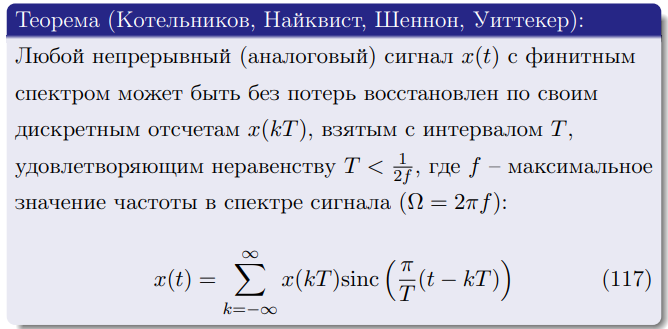

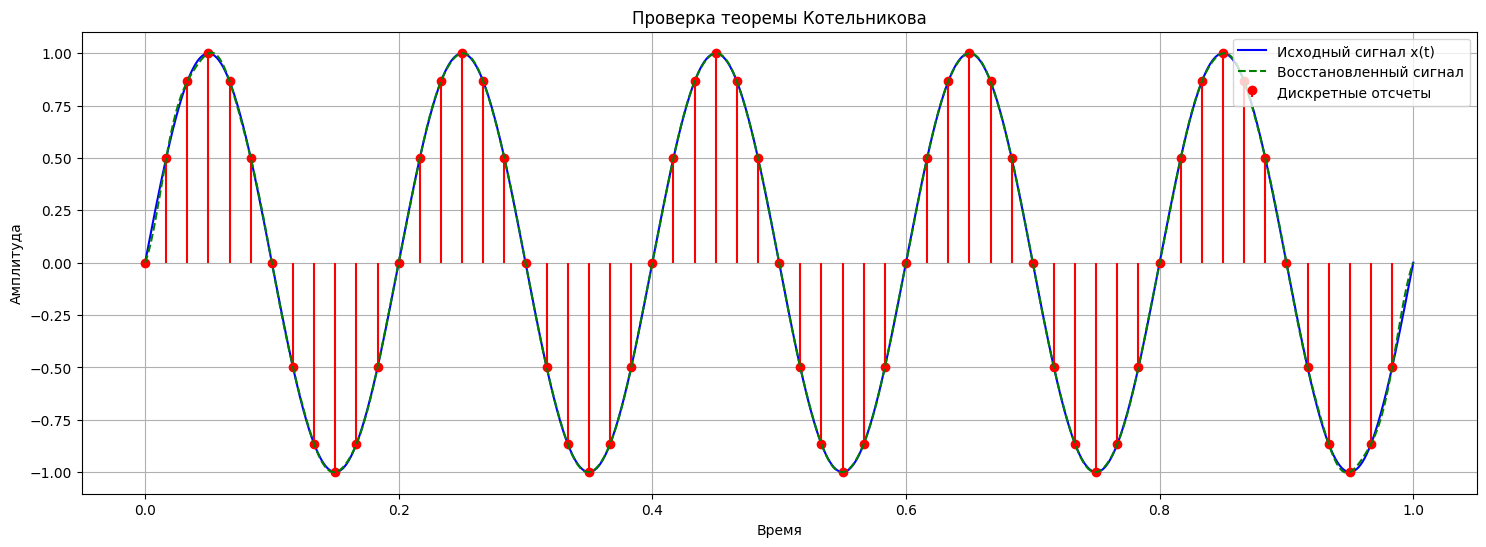

In [ ]:
# частота сигнала
f0 = 5
# угловая частота
ω0 = 2 * np.pi * f0
# частота дискретизации (нужно fs > 2 * f0)
fs = 60
# период дискретизации
T = 1 / fs

# временной интервал
t = np.linspace(0, 1, 5000)
# моменты дискретизации
t_samples = np.arange(0, 1, T)


# исходный сигнал
x = np.sin(ω0 * t)
# дискретные отсчеты
x_samples = np.sin(ω0 * t_samples)

# восстановление сигнала
def sinc_interpolation(t: np.array, samples: np.array, T: float) -> np.array:
    x_reconstructed = np.zeros_like(t)
    for n, x_n in enumerate(samples):
        x_reconstructed += x_n * np.sinc((t - n * T) / T)
    return x_reconstructed

x_reconstructed = sinc_interpolation(t, x_samples, T)

plt.figure(figsize=(18, 6))
plt.plot(t, x, "b", label="Исходный сигнал x(t)")
plt.stem(
    t_samples,
    x_samples,
    linefmt="r",
    markerfmt="ro",
    basefmt=" ",
    label="Дискретные отсчеты",
)
plt.plot(t, x_reconstructed, "g--", label="Восстановленный сигнал")
plt.title("Проверка теоремы Котельникова")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid()
plt.legend(loc="upper right")
plt.show()

# 2

In [ ]:
T = 20 # длительность сигнала
N = 20000 # число точек
t = np.linspace(-T / 2, T / 2, N, endpoint=False)
dt = t[1] - t[0] # шаг дискретизации

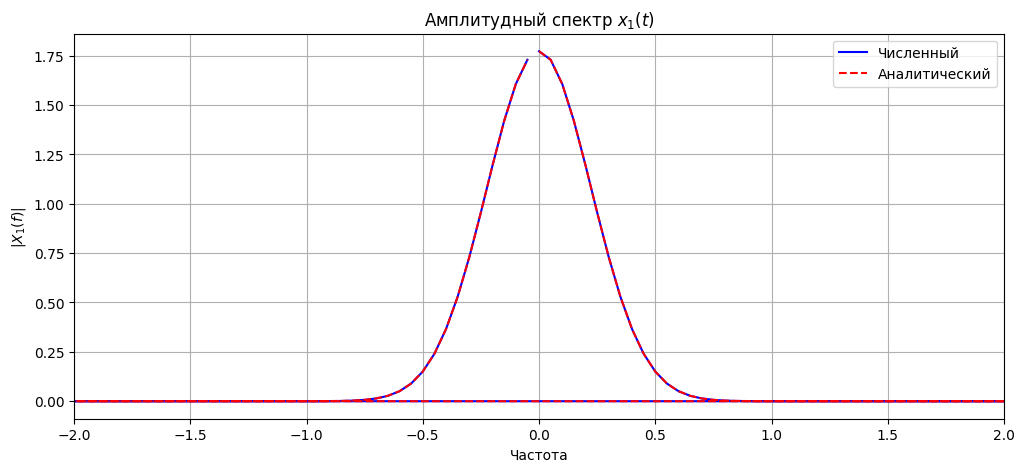

In [ ]:
x1 = np.exp(-t**2)

# ДПФ (БПФ)
fft_x1 = np.fft.fft(x1) * dt # масштабирование
freq = np.fft.fftfreq(N, dt)

# аналитический спектр
X1_analytic = np.sqrt(np.pi) * np.exp(-np.pi**2 * freq**2)

plt.figure(figsize=(12, 5))
plt.plot(freq, np.abs(fft_x1), "b", label="Численный")
plt.plot(freq, X1_analytic, "r--", label="Аналитический")
plt.title("Амплитудный спектр $x_1(t)$")
plt.xlabel("Частота")
plt.ylabel("$|X_1(f)|$")
plt.xlim(-2, 2)
plt.legend()
plt.grid()
plt.show()

C:\Users\reino\AppData\Local\Temp\ipykernel_25796\425850757.py:9: RuntimeWarning: divide by zero encountered in divide
  4 * np.pi * np.cos(2 * np.pi * freq) / (4 * np.pi**2 * freq**2 - np.pi**2)


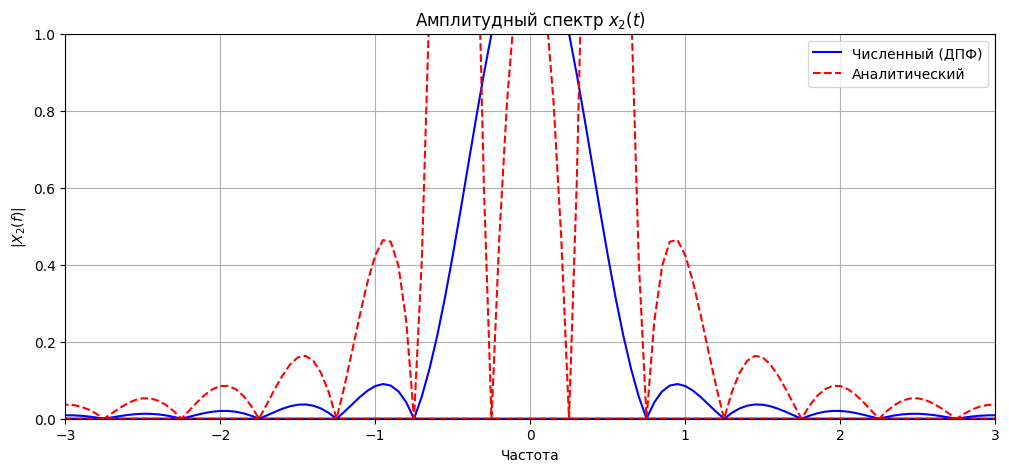

In [3]:
x2 = np.cos(np.pi * t / 2) * (np.abs(t) <= 1)

# ДПФ (БПФ)
fft_x2 = np.fft.fft(x2) * dt
freq = np.fft.fftfreq(N, dt)

# аналитический спектр
X2_analytic = np.abs(
    4 * np.pi * np.cos(2 * np.pi * freq) / (4 * np.pi**2 * freq**2 - np.pi**2)
)

plt.figure(figsize=(12, 5))
plt.plot(freq, np.abs(fft_x2), "b", label="Численный (ДПФ)")
plt.plot(freq, X2_analytic, "r--", label="Аналитический")
plt.title("Амплитудный спектр $x_2(t)$")
plt.xlabel("Частота")
plt.ylabel("$|X_2(f)|$")
plt.xlim(-3, 3)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

# 3

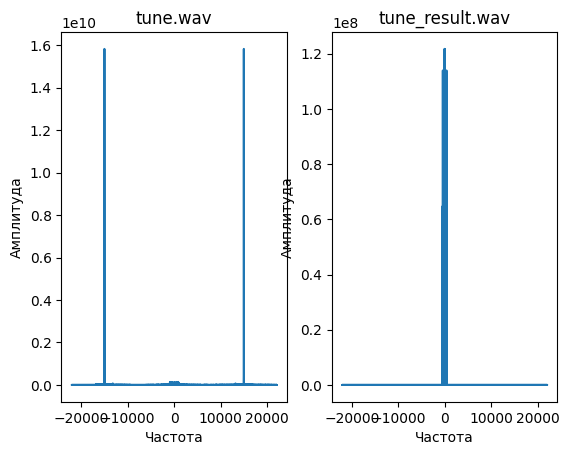

In [ ]:
fs, signal = wavfile.read(folder + "tune.wav")
n = signal.shape[0]

fig, axes = plt.subplots(1, 2)

spectrum = np.fft.fft(signal)
amplitude = np.abs(spectrum)
frequency = np.fft.fftfreq(n, 1 / fs)
axes[0].plot(frequency, amplitude)
axes[0].set_title("tune.wav")
axes[0].set_ylabel("Амплитуда")
axes[0].set_xlabel("Частота")

filtered_spectrum = np.array(spectrum)
filtered_spectrum[10000: -10000] = 0
axes[1].plot(frequency, np.abs(filtered_spectrum))
axes[1].set_title("tune_result.wav")
axes[1].set_ylabel("Амплитуда")
axes[1].set_xlabel("Частота")

plt.show()

filtered_signal = np.real(np.fft.ifft(filtered_spectrum)).astype(np.int16)
wavfile.write("tune_result.wav", fs, filtered_signal)

# 4

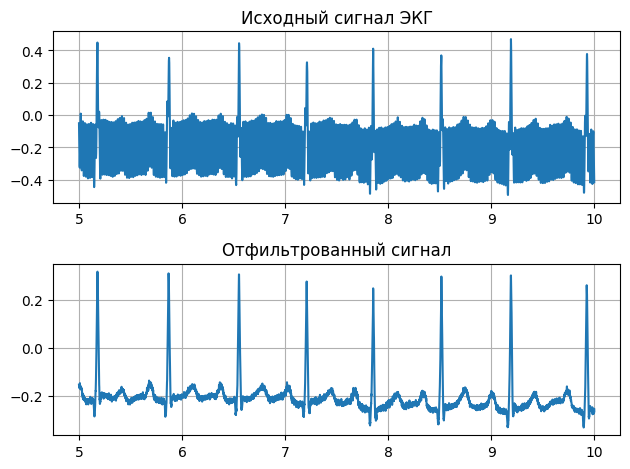

In [ ]:
f = open(folder + "ecg.dat")
data = f.readlines()
n = len(data)
f.close()

x = np.ndarray(n) # массив для временных меток (ось X)
y = np.ndarray(n) # массив для значений сигнала (ось Y)

for i in range(n):
    s = data[i].split()
    x[i] = float(s[0]) # временная метка
    y[i] = float(s[1]) # амплитуда сигнала

plt.subplot(2, 1, 1)
plt.grid()
plt.title("Исходный сигнал")
plt.plot(x[5000: 10000], y[5000: 10000])

duration = x[n - 1] - x[0] # общая длительность сигнала в секундах
sample_rate = int(n / duration) # частота дискретизации

yf = rfft(y) # прямое преобразование Фурье для вещественных сигналов
xf = rfftfreq(n, 1.0 / sample_rate) # массив частот для соответствующих компонент Фурье

for i in range(len(yf)):
    if xf[i] > 49.0 and xf[i] < 51.0:
        yf[i] = 0.0 # устраняем сетевые помехи (50 Гц)

ys = irfft(yf) # преобразуем отфильтрованный спектр обратно в сигнал

plt.subplot(2, 1, 2)
plt.grid()
plt.title("Отфильтрованный сигнал")
plt.plot(x[5000: 10000], ys[5000: 10000])

plt.tight_layout()
plt.show()

# 5

In [ ]:
fs, signal = wavfile.read(folder + "test5.wav")

y = np.fft.fft(signal)

# вычисляем размер одной четверти спектра
N = (len(y) - 1) // 2
N = N // 4

# нулевая частота и 4 части спектра
zero_frequency = y[0]
C = y[1: N + 1]
B = y[N + 1: 2 * N + 1]
D = y[2 * N + 1: 3 * N + 1]
A = y[3 * N + 1: 4 * N + 1]

# восстанавливаем исходный порядок спектра из переставленного [C, B, D, A]
# добавляем комплексно-сопряженные части в обратном порядке для симметрии
rearranged_y = np.hstack((
    zero_frequency,
    A,
    B,
    C,
    D,
    np.conj(D)[: : -1],
    np.conj(C)[: : -1],
    np.conj(B)[: : -1],
    np.conj(A)[: : -1],
))

filtered_signal = np.real(np.fft.ifft(rearranged_y)).astype(np.int16)
wavfile.write("test_5_result.wav", fs, filtered_signal)